In [3]:
import os, cv2
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)


Using device: cpu


In [2]:
class SDNETFastDataset(Dataset):
    def __init__(self, root_dir, img_size=64):
        self.samples = []
        self.transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor()
        ])

        crack_folders = {
            "bridge_deck": "CD",
            "walls": "CW",
            "pavements": "CP"
        }

        for main, sub in crack_folders.items():
            path = os.path.join(root_dir, main, sub)
            if os.path.exists(path):
                for f in os.listdir(path):
                    if f.lower().endswith(('.jpg','.png','.jpeg')):
                        self.samples.append(os.path.join(path, f))

        print("Total crack images found:", len(self.samples))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img = Image.open(self.samples[idx]).convert("RGB")
        img = self.transform(img)

        gray = img.mean(dim=0).numpy()
        edges = cv2.Canny((gray*255).astype(np.uint8), 50, 150)
        mask = torch.tensor(edges/255.0).unsqueeze(0).float()

        depth = cv2.GaussianBlur(edges, (5,5), 0)/255.0
        depth = torch.tensor(depth).unsqueeze(0).float()

        return img, mask, depth


In [3]:
DATASET_PATH = "SDNET2018"
dataset = SDNETFastDataset(DATASET_PATH)

train_subset = Subset(dataset, range(min(3000, len(dataset))))
loader = DataLoader(train_subset, batch_size=16, shuffle=True)

print("Training samples:", len(train_subset))


Total crack images found: 8484
Training samples: 3000


In [1]:
class FastUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = nn.Conv2d(3, 16, 3, padding=1)
        self.enc2 = nn.Conv2d(16, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2)

        self.dec1 = nn.Conv2d(32, 16, 3, padding=1)
        self.out = nn.Conv2d(16, 1, 1)

    def forward(self, x):
        e1 = torch.relu(self.enc1(x))
        e2 = torch.relu(self.enc2(self.pool(e1)))
        d1 = torch.nn.functional.interpolate(e2, scale_factor=2)
        d2 = torch.relu(self.dec1(d1))
        return torch.sigmoid(self.out(d2))


NameError: name 'nn' is not defined

In [6]:
model = FastUNet().to(DEVICE)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 10

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for imgs, masks, depths in tqdm(loader):
        imgs, depths = imgs.to(DEVICE), depths.to(DEVICE)

        optimizer.zero_grad()
        preds = model(imgs)
        loss = criterion(preds, depths)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {total_loss/len(loader):.4f}")


100%|██████████| 188/188 [00:26<00:00,  7.16it/s]


Epoch 1/10 | Loss: 0.0273


100%|██████████| 188/188 [00:25<00:00,  7.51it/s]


Epoch 2/10 | Loss: 0.0080


100%|██████████| 188/188 [00:26<00:00,  7.05it/s]


...

Epoch 8/10 | Loss: 0.0052


100%|██████████| 188/188 [00:27<00:00,  6.90it/s]


Epoch 9/10 | Loss: 0.0047


100%|██████████| 188/188 [00:27<00:00,  6.82it/s]

Epoch 10/10 | Loss: 0.0042


In [7]:
torch.save(model.state_dict(), "sdnet_fast_depth_model.pth")
print("Model saved: sdnet_fast_depth_model.pth")


Model saved: sdnet_fast_depth_model.pth


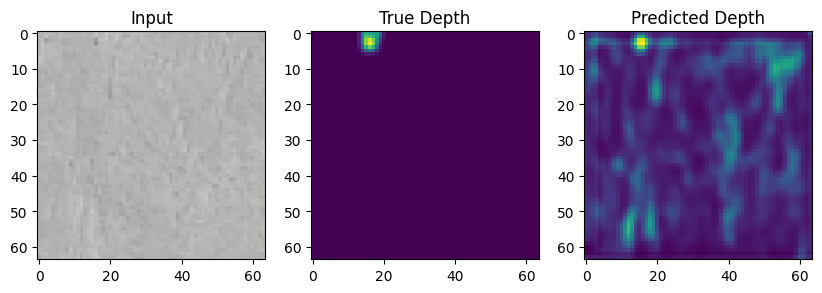

In [8]:
model.eval()
img, mask, depth = dataset[0]
with torch.no_grad():
    pred = model(img.unsqueeze(0).to(DEVICE)).cpu()[0][0]

plt.figure(figsize=(10,3))
plt.subplot(1,3,1); plt.title("Input"); plt.imshow(img.permute(1,2,0))
plt.subplot(1,3,2); plt.title("True Depth"); plt.imshow(depth[0])
plt.subplot(1,3,3); plt.title("Predicted Depth"); plt.imshow(pred)
plt.show()


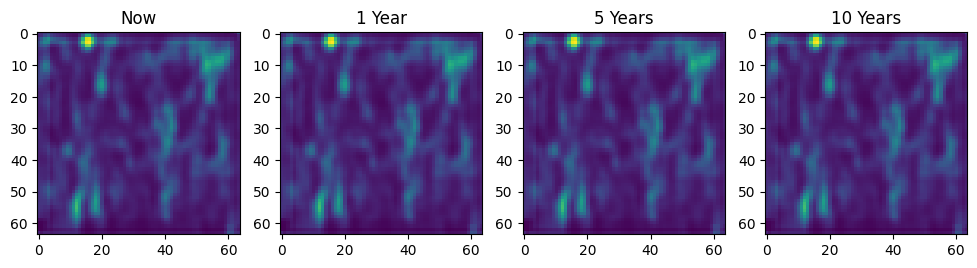

In [9]:
def future_depth(depth, years, alpha=0.06):
    return torch.clamp(depth * (1 + alpha*years), 0, 1)

plt.figure(figsize=(12,3))
plt.subplot(1,4,1); plt.title("Now"); plt.imshow(pred)
plt.subplot(1,4,2); plt.title("1 Year"); plt.imshow(future_depth(pred,1))
plt.subplot(1,4,3); plt.title("5 Years"); plt.imshow(future_depth(pred,5))
plt.subplot(1,4,4); plt.title("10 Years"); plt.imshow(future_depth(pred,10))
plt.show()
